# DeepVerse-Python Digital Twin Compressive Sensing Demo

## Introduction
This notebook provides a comprehensive workflow for digital twin based compressive sensing including:
1. **Dataset Generation** - Creating synthetic channel data using [DeepVerse 6G](https://deepverse6g.net/)
2. **Model Training** - Training the neural networks of channel encoder and RF beam predictor
3. **Inference** - Testing the trained model and extracting measurement vectors from channel encoder
4. **Visualization** - Plotting the patterns of measurement vectors

## Installation

In [1]:
# Installation needed starting from a fresh conda env
# This may not produce a torch installation supporting cuda and gpu
# %pip install torch numpy pandas tqdm scikit-learn requests deepverse scipy

## Import Python Package

In [2]:
# Import all necessary libraries
import os
import sys
import random
import shutil
import sklearn
import zipfile
import requests
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from pprint import pprint
from collections import OrderedDict
from scipy.io import loadmat, savemat
from deepverse import ParameterManager, Dataset

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Check if CUDA is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
def setup_seed(seed=0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

setup_seed(0)


Using device: cuda:0


# Digital twin synthetic data preparation
## Download DeepVerse data 
Here, we download the DeepVerse (synthetic) data. We use the DT1 scenario, which incoporates the LiDAR, RGB images, wireless, and position data modalities. Since this demo focuses on the compressive sensing for hybrid precoding application, we only download and use the wireless data modality.

The scenario folder follows the below structure
```
scenarios/
│  ├─ DT1/
│  │  ├─ wireless/
│  │  │  ├─ ...
│  │  │  ├─ params.mat
│  │  ├─ param/
│  │  │  ├─ config.m
│  │  ├─ scenario1.csv
```

In [3]:
def download_and_unzip(url, zip_path, extract_to):
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total = int(response.headers.get('content-length', 0))
    with open(zip_path, 'wb') as f, tqdm(
        desc=f"Downloading: {zip_path.name}",
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            size = f.write(chunk)
            bar.update(size)

    print(f"Infalting: {zip_path}")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
    except zipfile.BadZipFile:
        print(f"Error: {zip_path} is not a valid zip file!")
        return

    print(f"Removing zip: {zip_path}")
    zip_path.unlink()

In [4]:
# Set up directories
scenario_name = 'DT1'
scenario_dir = Path(f"scenarios/{scenario_name}")
scenario_dir.mkdir(parents=True, exist_ok=True)

# Download and extract wireless data
print("Preparing wireless data...")
download_and_unzip(
    "https://www.dropbox.com/scl/fi/esl0jd1idkwarmk9sr1xz/wireless.zip?rlkey=qhwdiu07oasfn1h9pa5xfjv0i&st=pjgypntm&dl=1",
    scenario_dir / "wireless.zip",
    scenario_dir
)

# Download and extract parameter files
print("Preparing parameter files...")
param_dir = scenario_dir / "param"
param_dir.mkdir(parents=True, exist_ok=True)
download_and_unzip(
    "https://www.dropbox.com/scl/fo/9sfd6u8912l7o407fqi30/AN2NIxPUrXvMEVjImsHmX2g?rlkey=qqxzkohhnmgjgz2abf6cvb32h&st=0kbpp7v4&dl=1",
    scenario_dir / "param.zip",
    param_dir
)

# Copy wireless params.mat file to wireless folder
wireless_dir = scenario_dir / "wireless"
shutil.copy(param_dir / "params.mat", wireless_dir / "params.mat")

print(f"DeepVerse scenario {scenario_name} is ready!")

Preparing wireless data...


Downloading: wireless.zip: 100%|██████████| 129M/129M [00:01<00:00, 89.1MB/s] 


Infalting: scenarios\DT1\wireless.zip
Removing zip: scenarios\DT1\wireless.zip
Preparing parameter files...


Downloading: param.zip: 100%|██████████| 3.19M/3.19M [00:00<00:00, 12.6MB/s]

Infalting: scenarios\DT1\param.zip
Removing zip: scenarios\DT1\param.zip
DeepVerse scenario DT1 is ready!


## DeepVerse dataset generation

In [5]:
# Path to the configuration file 
scenario_name = 'DT1'
config_path = f"scenarios/{scenario_name}/param/config.m"

# Initialize ParameterManager and load parameters
param_manager = ParameterManager(config_path)
param_manager.params["scenes"] = list(range(2411))
# param_manager.params["scenes"] = list(range(10))
param_manager.params["radar"]["enable"] = False
param_manager.params["comm"]["enable"] = True
param_manager.params["camera"] = False
param_manager.params["lidar"] = False
param_manager.params["position"] = True

param_manager.params["comm"]["OFDM"]["bandwidth"] = 30e3/1e9
param_manager.params["comm"]["OFDM"]["subcarriers"] = 1
param_manager.params["comm"]["OFDM"]["selected_subcarriers"] = list(range(0, 1))

param_manager.params["comm"]["bs_antenna"]["shape"] = [32, 1]
param_manager.params["comm"]["bs_antenna"]["rotation"] = [0, 0, 0]
param_manager.params["comm"]["bs_antenna"]["FoV"] = [180, 180]

param_manager.params["comm"]["ue_antenna"]["shape"] = [1, 1]
param_manager.params["comm"]["ue_antenna"]["rotation"] = [0, 0, 0]
param_manager.params["comm"]["ue_antenna"]["FoV"] = [360, 180]

# pprint(param_manager.params)

# Generate a dataset
dataset = Dataset(param_manager)

Generating mobility dataset: ⏳ In progress
Generating mobility dataset: ✅ Completed (0.00s)
Generating comm dataset: ⏳ In progress


Generating comm dataset: ✅ Completed (143.28s)


## Data post-processing
The generated DeepVerse dataset contains the communication channel between the base station and the user.

In the following blocks we apply post-processing on this data:
- We apply beamforming (from a DFT codebook) to the communication channel to get the optimal beam index
- We then save the data: Communication channel and optimal beam index

### Discrete Fourier transform (DFT) codebook

In [6]:
def UPA_codebook_generator_DFT(Mx, My, Mz, over_sampling_x=1, over_sampling_y=1, over_sampling_z=1, ant_spacing=0.5):
    """
    Generates a DFT-based codebook for a Uniform Planar Array (UPA).

    Args:
        Mx (int): Number of antenna elements on x-axis.
        My (int): Number of antenna elements on y-axis.
        Mz (int): Number of antenna elements on z-axis.
        over_sampling_x (int, optional): Oversampling factor along x-axis. Defaults to 1.
        over_sampling_y (int, optional): Oversampling factor along y-axis. Defaults to 1.
        over_sampling_z (int, optional): Oversampling factor along z-axis. Defaults to 1.
        ant_spacing (float, optional): Antenna spacing. Defaults to 0.5 (half wavelength).

    Returns:
        tuple: A tuple containing:
            - F_CB (np.ndarray): The generated UPA codebook.
            - all_beams (np.ndarray): A matrix of all beam indices for each axis.
    """
    
    antx_index = np.arange(Mx)
    anty_index = np.arange(My)
    antz_index = np.arange(Mz)
    
    codebook_size_x = over_sampling_x * Mx
    codebook_size_y = over_sampling_y * My
    codebook_size_z = over_sampling_z * Mz
    
    theta_qx = np.arange(codebook_size_x) * (2 * np.pi / codebook_size_x)
    F_CBx = (1 / np.sqrt(Mx)) * np.exp(-1j * np.outer(antx_index, theta_qx))
    
    theta_qy = np.arange(codebook_size_y) * (2 * np.pi / codebook_size_y)
    F_CBy = (1 / np.sqrt(My)) * np.exp(-1j * np.outer(anty_index, theta_qy))
    
    theta_qz = np.arange(codebook_size_z) * (2 * np.pi / codebook_size_z)
    F_CBz = (1 / np.sqrt(Mz)) * np.exp(-1j * np.outer(antz_index, theta_qz))
    
    F_CBxy = np.kron(F_CBy, F_CBx)
    F_CB = np.kron(F_CBz, F_CBxy)
    
    beams_x = np.arange(1, codebook_size_x + 1)
    beams_y = np.arange(1, codebook_size_y + 1)
    beams_z = np.arange(1, codebook_size_z + 1)
    
    Mxx_Ind = np.tile(beams_x, codebook_size_y * codebook_size_z)
    Myy_Ind = np.tile(np.tile(beams_y, codebook_size_x).reshape(-1, order='F'), codebook_size_z)
    Mzz_Ind = np.tile(beams_z, codebook_size_x * codebook_size_y)
    
    all_beams = np.column_stack((Mxx_Ind, Myy_Ind, Mzz_Ind))
    
    return F_CB, all_beams

### Save communication channel and optimal beam index

In [7]:
# Generate DFT codebook
num_tx_ant = param_manager.params["comm"]["bs_antenna"]["shape"][0]
num_rx_ant = param_manager.params["comm"]["ue_antenna"]["shape"][0]
F_CB, _ = UPA_codebook_generator_DFT(num_tx_ant, 1, 1)
print("Codebook Shape:", F_CB.shape)

# Define the output variables
num_scene = len(dataset.params['scenes'])
all_beam_idx = np.zeros((num_scene, 1))
all_channel = np.zeros((num_scene, num_rx_ant, num_tx_ant), dtype=np.complex64)

for i in range(num_scene):
    channel = dataset.get_sample('comm-ue', index=i, bs_idx=0, ue_idx=0).coeffs # [rx, tx, subcarriers]
    channel = np.squeeze(channel, axis=2) # [rx, tx]
    gain = abs(channel @ np.conj(F_CB)) # [rx, codebook_size]
    beam_idx = np.argmax(gain, axis=1)
    all_beam_idx[i] = beam_idx 
    all_channel[i, :, :] = channel

print("All Beam Indices Shape:", all_beam_idx.shape)
print("All Channel Shape:", all_channel.shape)

# Define the output directory
output_dir = f"datasets/{scenario_name}"
os.makedirs(output_dir, exist_ok=True)

# Save the output variables
savemat(
    os.path.join(output_dir, "dataset.mat"), 
    {"all_beam_idx": all_beam_idx, "all_channel": all_channel})

Codebook Shape: (32, 32)
All Beam Indices Shape: (2411, 1)
All Channel Shape: (2411, 1, 32)


## Create deep learning training and testing datasets
Here, we divide the full dataset to training and testing datasets.

In [8]:
def generate_csvs(num_data, percentage):
    # 1. Generate a list of numbers from 0 to n-1
    numbers = list(range(num_data))
    
    # 2. Shuffle these numbers randomly
    random.shuffle(numbers)
    
    # Calculate the split point
    split_point = int(num_data * percentage)
    
    # 3. Split the list
    train_idx = numbers[:split_point]
    test_idx = numbers[split_point:]
    
    # 4. Convert lists to pandas dataframes
    df1 = pd.DataFrame(train_idx, columns=["data_idx"])
    df2 = pd.DataFrame(test_idx, columns=["data_idx"])
    
    # 5. Save the dataframes to CSV files
    return df1, df2

In [9]:
data_path = f"datasets/{scenario_name}/dataset.mat"
data = loadmat(data_path)['all_channel']
num_data = data.shape[0]
percentage = 0.8
(df1, df2) = generate_csvs(num_data, percentage)

df1.to_csv('/'.join(data_path.split('/')[:-1])+'/train_data_idx.csv', index=False)
df2.to_csv('/'.join(data_path.split('/')[:-1])+'/test_data_idx.csv', index=False)

## Deep learning demo
In the following blocks we train a nerual network for channel encoding and RF beam prediction using digital twin
- The input of the neural network is the communication channel
- The ground-truth output of the neural network is a one-hot vector for the optimal beam index
- The loss function for training is the cross-entropy
- We train and test the neural network on the digital twin synthetic data

### Set up configurations

In [10]:
class configurations(object):
    def __init__(self):
        # Dataset param.
        self.real_data_root = "datasets/DT1"
        self.synth_data_root = "datasets/DT1"
        self.train_csv = "train_data_idx.csv"
        self.test_csv = "test_data_idx.csv"
        self.N_BS = 32
        self.N_MS = 1
        self.M_BS = 4
        self.M_MS = 1

        # Train param.
        self.num_train_data = 10240
        self.batch_size = 32
        self.learning_rate = 1e-2
        self.num_epochs = 150
        self.gpu = 0

config = configurations()
config.load_model_path = None
config.finetune = None
config.store_model_path = os.path.join(
    "results",
    "DT1",
    f"results_DT_{config.N_BS}x1_dict_size_{config.M_BS}",
)

# Get output directory ready
if not os.path.isdir(config.store_model_path):
    os.makedirs(config.store_model_path)

### Create dataloader

In [11]:
def create_samples(data_root, csv_path, random_state, num_data_point, portion, select_data_idx):
    # Load channel data and beam indices
    channel = loadmat(os.path.join(data_root, "dataset.mat"))['all_channel']
    beam_idx = loadmat(os.path.join(data_root, "dataset.mat"))['all_beam_idx']
    
    # Load data indices
    if select_data_idx is None:
        data_idx = pd.read_csv(os.path.join(data_root, csv_path))["data_idx"].to_numpy()
    else:
        data_idx = select_data_idx
    
    channel = channel[data_idx, ...]
    beam_idx = beam_idx[data_idx, ...]
    
    # Shuffle
    channel, beam_idx, data_idx = sklearn.utils.shuffle(channel, beam_idx, data_idx, random_state=random_state)
    
    if num_data_point:
        channel = channel[:num_data_point, ...]
        beam_idx = beam_idx[:num_data_point, ...]
        data_idx = data_idx[:num_data_point, ...]
    else:
        num_data = beam_idx.shape[0]
        p = int(num_data*portion)
        
        channel = channel[:p, ...]
        beam_idx = beam_idx[:p, ...]
        data_idx = data_idx[:p, ...]
        
    # Normalization
    channel /= np.linalg.norm(channel, ord='fro', axis=(-1, -2), keepdims=True)  
    
    return channel, beam_idx, data_idx

In [12]:
class DataFeed(Dataset):
    def __init__(self, data_root, csv_path, random_state=0, num_data_point=None, portion=1.0, select_data_idx=None):
        self.data_root = data_root
        self.channel, self.label, self.data_idx = create_samples(data_root, csv_path, random_state, num_data_point, portion, select_data_idx)
        
    def __len__(self):
        return len(self.label)
    
    def __getitem__(self, idx):
        channel = self.channel[idx, ...]
        label = self.label[idx, 0]
        data_idx = self.data_idx[idx, ...]
        
        channel = torch.tensor(channel, requires_grad=False)
        label = torch.tensor(label, requires_grad=False)
        data_idx = torch.tensor(data_idx, requires_grad=False)
        
        return channel.cfloat(), label.long(), data_idx.long()

In [13]:
# Create dataloader
train_loader = DataLoader(
    DataFeed(config.synth_data_root, config.train_csv, num_data_point=config.num_train_data),
    batch_size=config.batch_size,
    shuffle=True
)

### Define deep learning model

In [14]:
class ConvPrecoder_MISO(nn.Module):
    # Input: (batch_size, 1, N_BS*N_MS) vectorized channel
    # Output: (batch_size, N_BS) codeword
    def __init__(self, dims, num_classes):
        super().__init__()
        
        N_BS = dims[0]
        N_MS = dims[1]
        M_BS = dims[2]
        M_MS = dims[3]
        
        self.BS_filters = nn.Conv1d(1, M_BS, kernel_size=N_BS, stride=N_BS, 
                                    padding='valid', dtype=torch.cfloat, bias=True)
        
        self.linear_layers = [nn.Linear(2*M_BS*M_MS, N_BS*N_MS),
                              nn.Linear(N_BS*N_MS, N_BS*N_MS)]
        self.linear_layers = nn.ModuleList(self.linear_layers)
        
        self.pred_layer = nn.Linear(N_BS*N_MS, num_classes)
        
    def forward(self, x):
        out = self.BS_filters(x) # (batch_size, M_BS, 1)
        
        out = torch.view_as_real(out) # (batch_size, M_BS, 1, 2)
        out = torch.reshape(out, (out.shape[0], -1)) # (batch_size, 2*M_BS)
        
        for i in range(len(self.linear_layers)):
            out = self.linear_layers[i](out)
            out = torch.sigmoid(out)
            
        out = self.pred_layer(out)
        
        return out 

### Train the model

In [15]:
# Build the model
dims = [config.N_BS, config.N_MS, config.M_BS, config.M_MS]
num_classes = config.N_BS
model = ConvPrecoder_MISO(dims, num_classes)

# Setup the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
model = model.to(device)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[100], gamma=0.1
)
print("Finish building model")

# Define loss function
loss_function = nn.CrossEntropyLoss()

# Training
for epoch in range(config.num_epochs):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    with tqdm(train_loader, unit="batch", file=sys.stdout) as tepoch:
        for i, data in enumerate(tepoch, 0):
            tepoch.set_description(f"Epoch {epoch}")
            
            # Get the inputs
            channel, beam_idx = data[0].to(device), data[1].to(device)
        
            # Set the parameter gradients to zero
            optimizer.zero_grad()
            
            # Forward + Backward + Optimize
            pred_idx = model(channel)
            loss = loss_function(pred_idx, beam_idx)
            # Orthonormal regularization
            if config.M_BS > 1: 
                kernel = torch.squeeze(model.BS_filters.weight).to(device)
                loss_ort = torch.norm(torch.matmul(kernel, torch.t(torch.conj(kernel))) - torch.eye(config.M_BS).to(device), 'fro')
                loss += 1e-1 * loss_ort
            
            loss.backward()
            optimizer.step()
            
            acc = torch.sum(pred_idx.argmax(1) == beam_idx).item() / config.batch_size
            
            # Normalize the conv. weights
            with torch.no_grad():
                model.BS_filters.weight /= torch.abs(model.BS_filters.weight) # constant-modulus
                model.BS_filters.weight *= 1/(config.N_BS**.5) # Unit norm
            
            # Pring statistics
            running_loss = (loss.item() + i * running_loss) / (i + 1)
            running_acc = (acc + i * running_acc) / (i + 1)
            log = OrderedDict()
            log["loss"] = "{:.6e}".format(running_loss)
            log["acc"] = running_acc
            tepoch.set_postfix(log)
        scheduler.step()

# Save model   
if config.store_model_path:
    torch.save(model.state_dict(), os.path.join(config.store_model_path, "demo.ckpt"))

Finish building model
Epoch 149: 100%|██████████| 61/61 [00:00<00:00, 86.83batch/s, loss=2.011670e-01, acc=0.946]


### Test the model

In [16]:
# Prepare test data
test_feed = DataFeed(config.real_data_root, config.test_csv)
test_loader = DataLoader(test_feed, batch_size=1024)

# Build model
model = ConvPrecoder_MISO(dims, num_classes)
model.load_state_dict(torch.load(os.path.join(config.store_model_path, "demo.ckpt")))
model = model.to(device)
print("Finish building model")

# Testing
model.eval()
with torch.no_grad():
    test_acc = []
    test_data_idx = []
    
    for data in test_loader:
        # Get the inputs
        channel, beam_idx, data_idx = data[0].to(device), data[1].to(device), data[2].to(device)
        
        # Forward
        pred_idx = model(channel)
        acc = torch.sum(pred_idx.argmax(1) == beam_idx).item()
        
        test_acc.append(acc)
        test_data_idx.append(data_idx.numpy(force=True))
        
    test_acc = np.array(test_acc)
    test_data_idx = np.concatenate(test_data_idx)

test_acc = np.array(test_acc)
avg_test_acc = np.sum(test_acc) / len(test_feed) * 100  
print(f"Test accuracy: {avg_test_acc:.2f}%")

# Save measurment vectors
BS_meas_vectors = torch.squeeze(model.BS_filters.weight)
if BS_meas_vectors.dim() == 2:
    BS_meas_vectors = torch.transpose(BS_meas_vectors, 0, 1)
else:
    BS_meas_vectors = torch.unsqueeze(BS_meas_vectors, 1)

mdic = {"BS_meas_vecs": BS_meas_vectors.numpy(force=True)}
savemat(os.path.join(config.store_model_path, f"meas_vecs_M_{config.M_BS}.mat"), mdic)

Finish building model
Test accuracy: 85.51%


### Plot the learned measurement vectors

In [17]:
def UPA_codebook_generator(Mx, My, Mz, over_sampling_x, over_sampling_y, over_sampling_z, ant_spacing):
    """
    Generate UPA codebook for beamforming

    Parameters:
    Mx, My, Mz: Number of antenna elements in each dimension
    over_sampling_x, over_sampling_y, over_sampling_z: Oversampling factors
    ant_spacing: Antenna spacing

    Returns:
    F_CB: Codebook matrix
    all_beams: Beam indices
    """

    kd = 2 * np.pi * ant_spacing
    antx_index = np.arange(Mx)
    anty_index = np.arange(My)
    antz_index = np.arange(Mz)
    M = Mx * My * Mz

    # Codebook sizes
    codebook_size_x = over_sampling_x * Mx
    codebook_size_y = over_sampling_y * My
    codebook_size_z = over_sampling_z * Mz

    # X-direction codebook
    theta_qx = np.linspace(0, np.pi - 1e-6, codebook_size_x)
    F_CBx = np.zeros((Mx, codebook_size_x), dtype=complex)
    for i in range(len(theta_qx)):
        F_CBx[:, i] = np.sqrt(1/Mx) * np.exp(-1j * kd * antx_index * np.cos(theta_qx[i]))

    # Y-direction codebook
    theta_qy = np.linspace(0, np.pi - 1e-6, codebook_size_y)
    F_CBy = np.zeros((My, codebook_size_y), dtype=complex)
    for i in range(len(theta_qy)):
        F_CBy[:, i] = np.sqrt(1/My) * np.exp(-1j * kd * anty_index * np.cos(theta_qy[i]))

    # Z-direction codebook
    theta_qz = np.linspace(0, np.pi - 1e-6, codebook_size_z)
    F_CBz = np.zeros((Mz, codebook_size_z), dtype=complex)
    for i in range(len(theta_qz)):
        F_CBz[:, i] = np.sqrt(1/Mz) * np.exp(-1j * kd * antz_index * np.cos(theta_qz[i]))

    # Combine codebooks
    F_CBxy = np.kron(F_CBy, F_CBx)
    F_CB = np.kron(F_CBz, F_CBxy)

    # Beam indices
    beams_x = np.arange(1, codebook_size_x + 1)
    beams_y = np.arange(1, codebook_size_y + 1)
    beams_z = np.arange(1, codebook_size_z + 1)

    Mxx_Ind = np.tile(beams_x, codebook_size_y * codebook_size_z)
    Myy_Ind = np.tile(np.tile(beams_y, codebook_size_x).reshape(-1, order='F'), codebook_size_z)
    Mzz_Ind = np.tile(beams_z, codebook_size_x * codebook_size_y)

    Tx = np.stack([Mxx_Ind, Myy_Ind, Mzz_Ind], axis=1)
    all_beams = Tx

    return F_CB, all_beams

def plot_pattern(vec, fig=None, ax=None, label=None):
    """
    Plot the radiation pattern of a measurement vector

    Parameters:
    vec: Input measurement vector (column vector)
    fig: Optional figure to use (if None, creates new figure)
    ax: Optional axis to use (if None, creates new axis)
    label: Optional label for the plot
    """

    # Ensure vec is a column vector
    if vec.ndim == 1:
        vec = vec.reshape(-1, 1)

    My = vec.shape[0]
    over_sampling_y = 1000

    # Generate codebook
    F, _ = UPA_codebook_generator(1, My, 1, 1, over_sampling_y, 1, 0.5)

    # Angular sampling
    theta_s = np.linspace(0, np.pi - 1e-6, over_sampling_y * My)

    # Project vector onto codebook
    projection = F.conj().T @ vec  # F.H @ vec (Hermitian transpose)
    proj = np.abs(projection)**2

    # Find maximum
    argidx = np.argmax(proj)

    # Create polar plot if not provided
    if fig is None and ax is None:
        fig = plt.figure(1, figsize=(8, 6))
        ax = fig.add_subplot(111, polar=True)

        # Configure plot (only for new plots)
        ax.grid(True, alpha=0.25)
        ax.set_rlabel_position(90)

    # Plot each beam
    for n in range(vec.shape[1]):
        if label is not None and vec.shape[1] == 1:
            ax.plot(theta_s, proj[:, n], linewidth=2, label=label)
        else:
            ax.plot(theta_s, proj[:, n], linewidth=2, label=f'Beam {n+1}' if label is None else label)

    # Add legend if multiple beams or if we have labels
    if vec.shape[1] > 1 or label is not None:
        ax.legend()

    return fig, ax

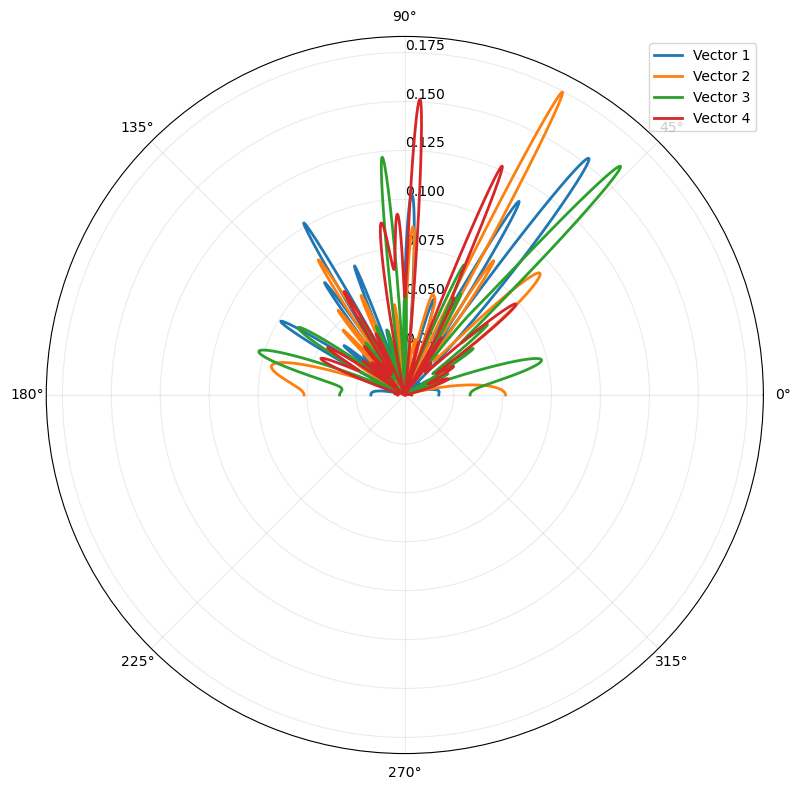

In [18]:
# Load measurement vectors
data = loadmat(os.path.join(config.store_model_path, f"meas_vecs_M_{config.M_BS}.mat"))
BS_meas_vecs = data['BS_meas_vecs']

# Create a single figure for all patterns
fig = plt.figure(1, figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Configure plot
ax.grid(True, alpha=0.25)
ax.set_rlabel_position(90)

# Plot each measurement vector on the same plot
for i in range(BS_meas_vecs.shape[1]):
    fig, ax = plot_pattern(BS_meas_vecs[:, i], fig=fig, ax=ax, label=f'Vector {i+1}')

plt.tight_layout()
plt.show()